In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs("charts", exist_ok=True)

df=pd.read_excel("library_dataset.xlsx", engine="openpyxl")

df.head()
df.info()
df.describe()
df['Issue_Date'] = pd.to_datetime(df['Issue_Date'])
df['Due_Date'] = pd.to_datetime(df['Due_Date'])
df['Return_Date'] = pd.to_datetime(df['Return_Date'])
df['Return_Date'] = df['Return_Date'].fillna(df['Due_Date'])
df['Days_Overdue'] = (df['Return_Date'] - df['Due_Date']).dt.days
df['Days_Overdue'] = df['Days_Overdue'].apply(lambda x: max(x, 0))
df['Fine_Paid'] = df['Fine_Paid'].astype(str)
df['Issue_Month'] = df['Issue_Date'].dt.month
df['Is_Overdue'] = df['Days_Overdue'] > 0

FileNotFoundError: [Errno 2] No such file or directory: 'library_dataset.xlsx'

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Transaction_ID  1042 non-null   object        
 1   Student_ID      1042 non-null   object        
 2   Book_ID         1042 non-null   object        
 3   Book_Title      1042 non-null   object        
 4   Genre           1042 non-null   object        
 5   Issue_Date      1042 non-null   datetime64[ns]
 6   Due_Date        1042 non-null   datetime64[ns]
 7   Return_Date     1042 non-null   datetime64[ns]
 8   Days_Overdue    1042 non-null   int64         
 9   Fine_INR        1042 non-null   int64         
 10  Fine_Paid       1042 non-null   object        
 11  Issue_Month     1042 non-null   int32         
 12  Is_Overdue      1042 non-null   bool          
dtypes: bool(1), datetime64[ns](3), int32(1), int64(2), object(6)
memory usage: 94.8+ KB


Transaction_ID    0
Student_ID        0
Book_ID           0
Book_Title        0
Genre             0
Issue_Date        0
Due_Date          0
Return_Date       0
Days_Overdue      0
Fine_INR          0
Fine_Paid         0
Issue_Month       0
Is_Overdue        0
dtype: int64

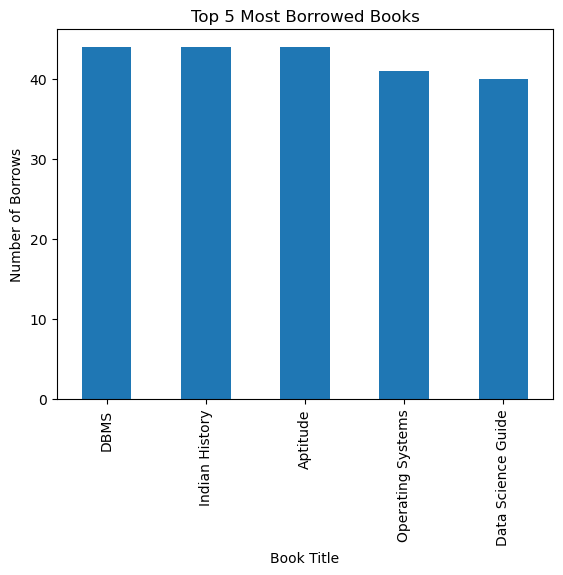

In [ ]:

top_books = df['Book_Title'].value_counts().head(5)

top_books.plot(kind='bar', title='Top 5 Most Borrowed Books')

plt.xlabel("Book Title")
plt.ylabel("Number of Borrows")

plt.savefig("charts/chart1_books.png")
plt.show()

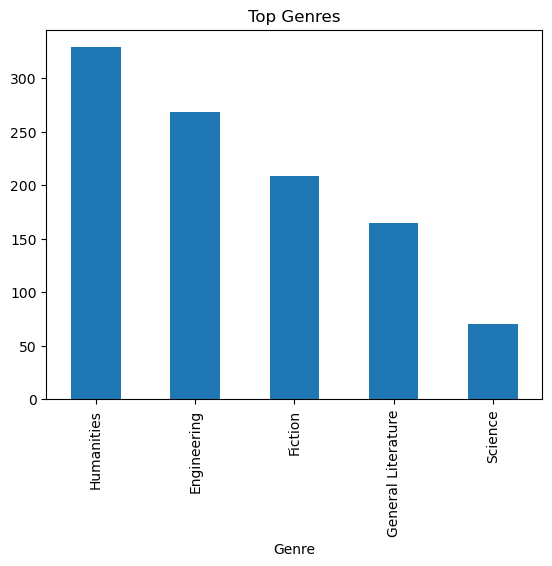

In [ ]:
df['Genre'].value_counts().head(5).plot(kind='bar', title='Top Genres')
plt.savefig("charts/chart2_genre.png")
plt.show()

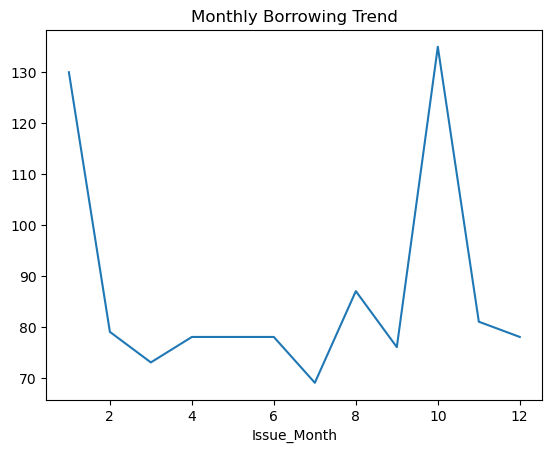

In [ ]:
df.groupby('Issue_Month').size().plot(kind='line', title='Monthly Borrowing Trend')
plt.savefig("charts/chart3_monthly.png")
plt.show()

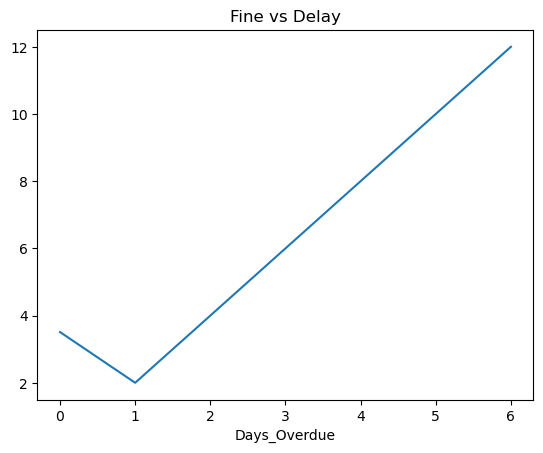

In [ ]:
df.groupby('Days_Overdue')['Fine_INR'].mean().plot(kind='line', title='Fine vs Delay')
plt.savefig("charts/chart4_fine.png")
plt.show()

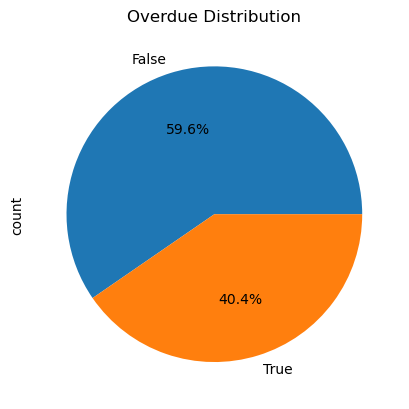

In [ ]:
df['Is_Overdue'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Overdue Distribution')
plt.savefig("charts/chart5_overdue.png")
plt.show()

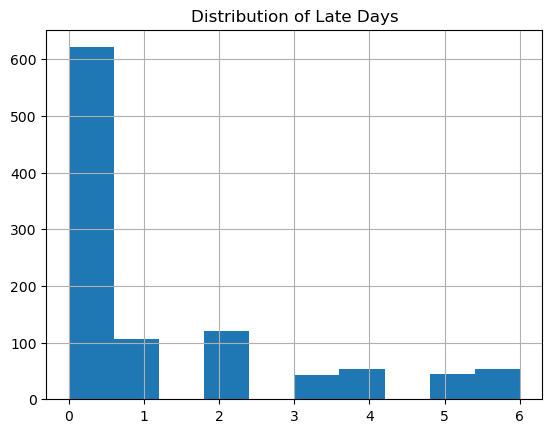

In [ ]:
df['Days_Overdue'].hist()
plt.title("Distribution of Late Days")
plt.savefig("charts/chart6_late_days.png")
plt.show()